In [32]:
# ---------- Import Libraries ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')
# ---------- Download NLTK Data ----------
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Riddhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Riddhi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [33]:
# Loading Dataset
df = pd.read_csv("Resume_DataSet.csv")

# Exploratory Data Analysis

In [34]:
print(df.head(5))

       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...
3  Data Science  Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4  Data Science  Education Details \r\n MCA   YMCAUST,  Faridab...


In [35]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB
None


In [36]:
print(df.describe())

              Category                                             Resume
count              962                                                962
unique              25                                                166
top     Java Developer  Technical Skills Web Technologies: Angular JS,...
freq                84                                                 18


In [37]:
print(df.shape)

(962, 2)


In [38]:
print(df.isnull().sum())

Category    0
Resume      0
dtype: int64


In [39]:
df = df.drop_duplicates()

In [45]:
# Text cleaning
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.replace('â¢', ' ')                  
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)
df['clean_resume'] = df['Resume'].apply(clean_text)

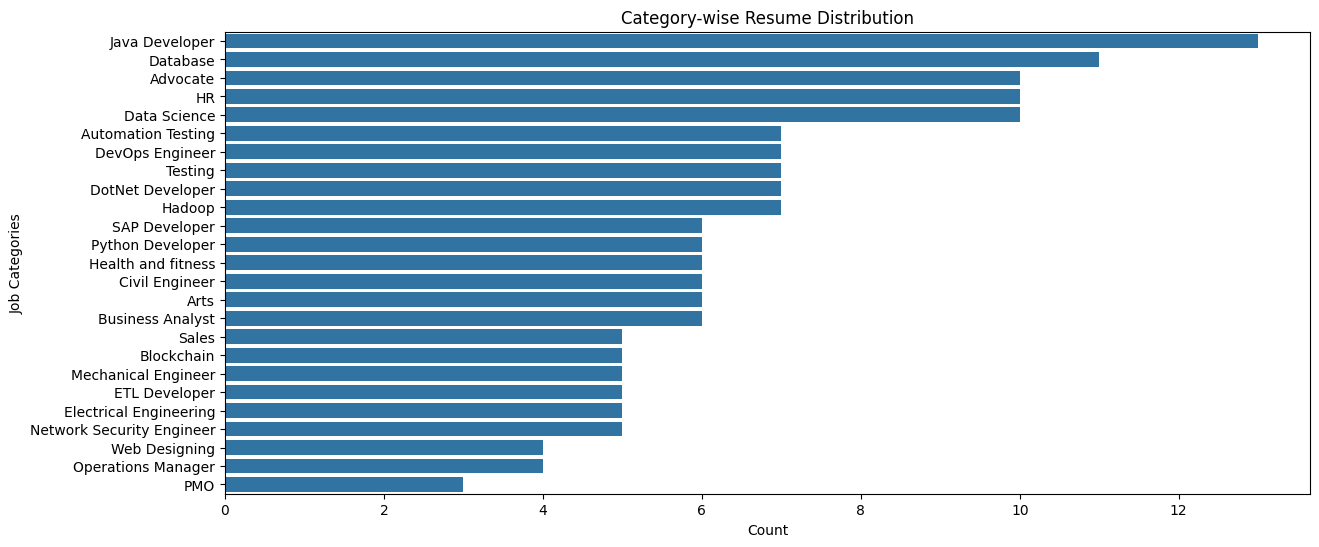

In [46]:
# Category-wise distribution 
plt.figure(figsize=(14,6))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index)
plt.title("Category-wise Resume Distribution")
plt.xlabel("Count")
plt.ylabel("Job Categories")
plt.show()

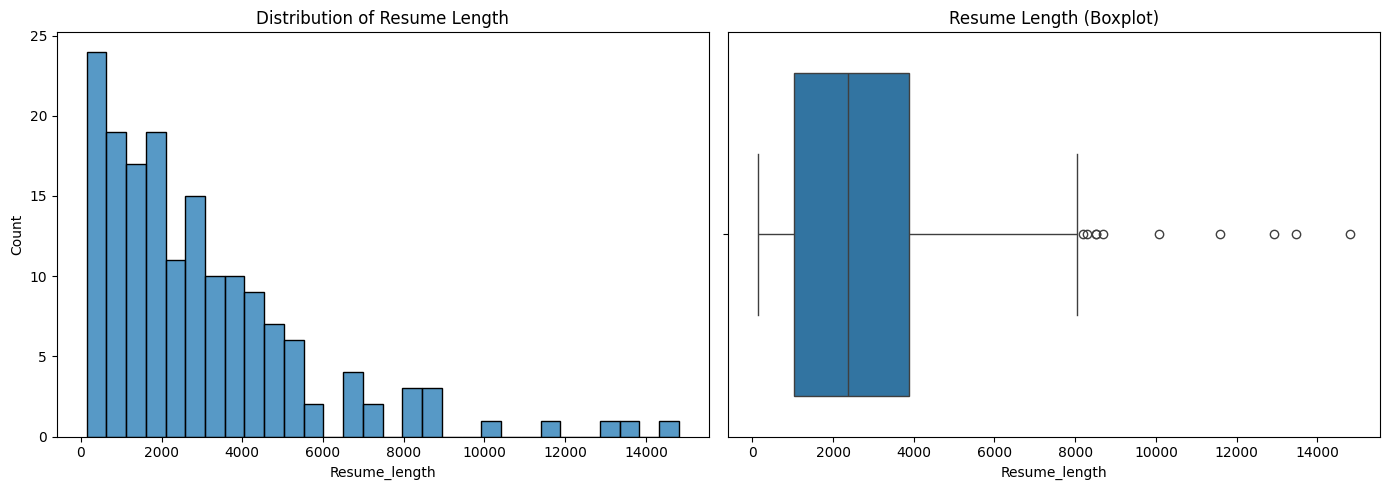

In [47]:
# Resume length analysis
df['Resume_length'] = df['Resume'].apply(len)
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)  # Histogram
sns.histplot(df['Resume_length'], bins=30)
plt.title("Distribution of Resume Length")
plt.subplot(1,2,2)  # Boxplot
sns.boxplot(x=df['Resume_length'])
plt.title("Resume Length (Boxplot)")
plt.tight_layout()
plt.show()

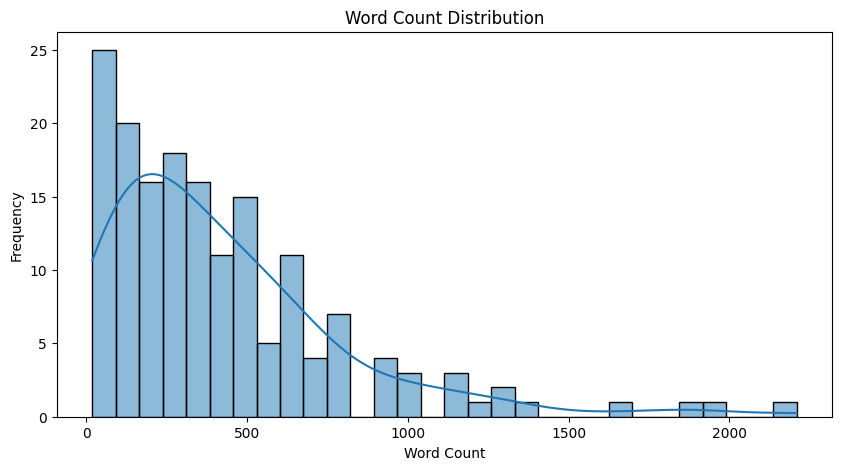

In [48]:
# Word count analysis
df['Word_count'] = df['Resume'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10,5))
sns.histplot(df['Word_count'], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

          Word  Frequency
0    exprience        616
1      company        595
2  description        540
3      details        531
4      project        525
5       months        524
6         data        386
7   management        315
8     database        275
9         team        265


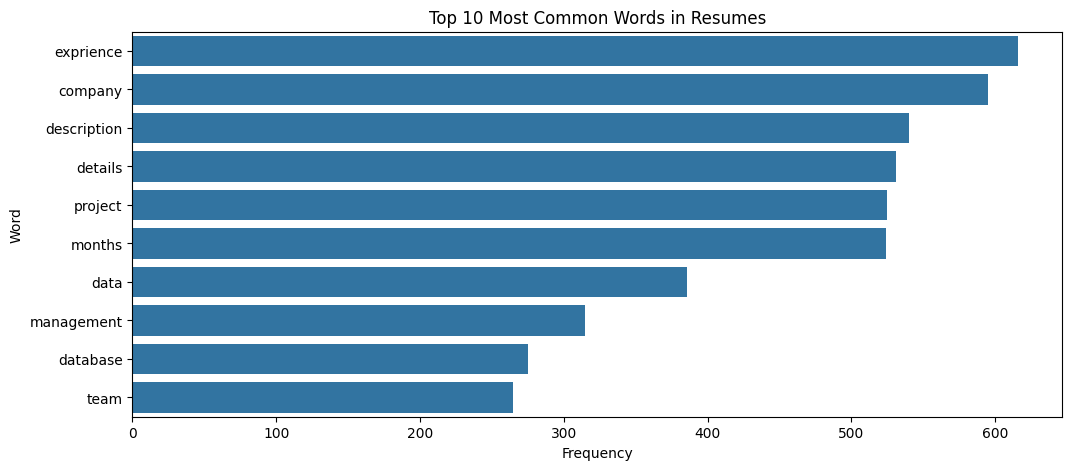

In [49]:
# Most frequent words in resumes analysis
from collections import Counter
all_words = ' '.join(df['clean_resume'].astype(str)).lower().split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(10)
common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
print(common_df)
plt.figure(figsize=(12,5))
sns.barplot(x='Frequency', y='Word', data=common_df)
plt.title("Top 10 Most Common Words in Resumes")
plt.show()

In [14]:
# Splitting feature and target
X = df['clean_resume']
y = df['Category']

In [15]:
# Label encoding categorical columns
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.2,random_state=42,stratify=y)

In [17]:
# TF-IDF vectorization 
tfidf = TfidfVectorizer(max_features=1000,stop_words='english',ngram_range=(1,2),)
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [18]:
# Creating models
models = { 
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(alpha=0.1),
    "SVM": LinearSVC(max_iter=3000,random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42)
}

In [19]:
# Train , evaluate and find best model
results=[]
best_model = None
best_accuracy = 0
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append([model_name,accuracy])
    print("Model:", model_name)
    print("Accuracy:", accuracy)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    # save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
print("Best Model Selected: ",best_model)
print("Best Accuracy:", best_accuracy)

Model: Logistic Regression
Accuracy: 0.6470588235294118

Classification Report:

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         1
           2       0.33      1.00      0.50         1
           3       0.00      0.00      0.00         1
           4       0.50      1.00      0.67         1
           5       1.00      1.00      1.00         1
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         2
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         2
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         1
          15       0.43      1.00      0.60         3


In [20]:
# Compare accuracy of models
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.647059
1          Naive Bayes  0.794118
2                  SVM  0.852941
3        Random Forest  0.823529


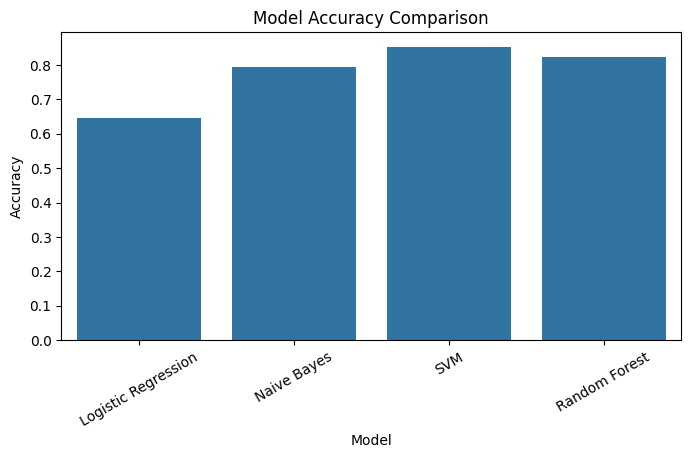

In [51]:
# Plotting accuracy comparison
plt.figure(figsize=(8,4))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.show()

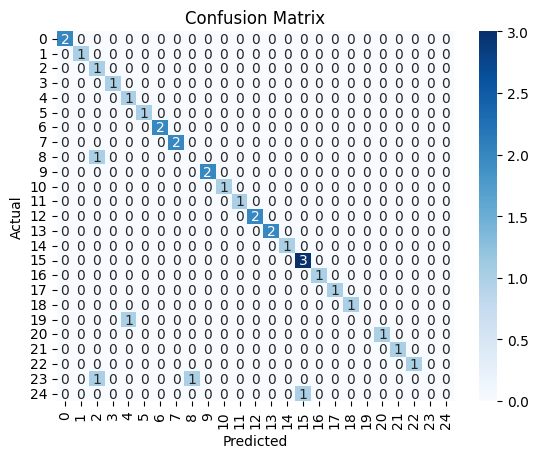

In [22]:
# Confusion Matrix 
svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

        Feature  Coefficient
384          hr     0.182746
448        java     0.174102
245   developer     0.172986
713      python     0.169986
687     project     0.162302
779         sap     0.161529
60   automation     0.159093
284  electrical     0.155227
193        data     0.154659
196    database     0.152400


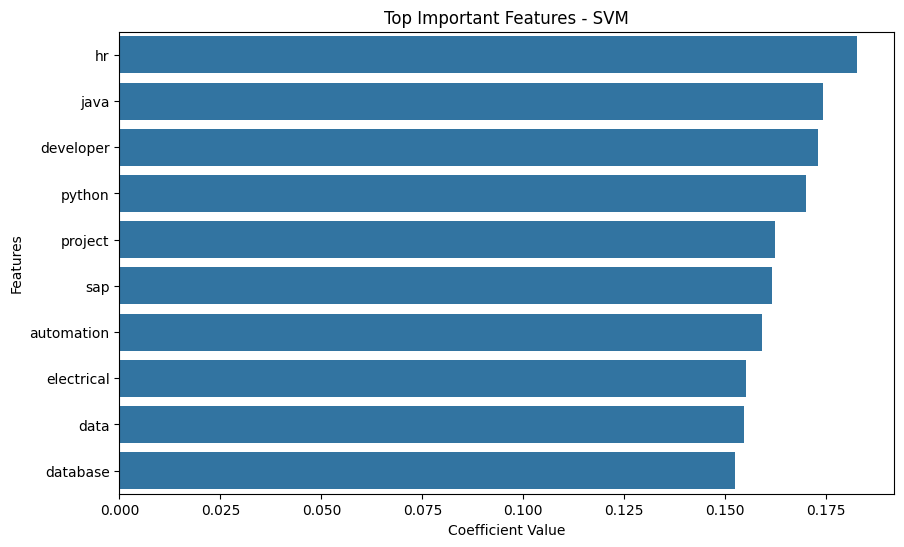

In [23]:
# Feature Importance - SVM Model
feature_names = tfidf.get_feature_names_out()
coefficients = np.mean(np.abs(svm.coef_), axis=0)
feature_importance = pd.DataFrame({'Feature': feature_names,'Coefficient': coefficients})
feature_importance = feature_importance.sort_values(by='Coefficient',ascending=False)
print(feature_importance.head(10))
plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient',y='Feature',data=feature_importance.head(10))
plt.title('Top Important Features - SVM')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

In [24]:
# JOB DESCRIPTIONS
job_descriptions = {"Data Science": """ Python SQL Machine Learning Deep Learning NLP Statistics Data Analysis Power BI Tableau
    Pandas NumPy Scikit-learn Data Visualization """,
    "HR": """ Recruitment Talent Acquisition Payroll Employee Engagement Communication HR Policies Performance Management """,
    "Advocate": """ Legal Research Corporate Law Litigation Documentation Client Handling Legal Drafting Compliance Intellectual Property """,
    "Arts": """ Creativity Designing Sketching Painting Communication Adobe Photoshop Illustrator Visual Arts Graphic Designing """,
    "Web Designing": """ HTML CSS JavaScript Bootstrap React UI UX Responsive Design Frontend Development Web Development Figma """,
    "Mechanical Engineer":""" AutoCAD SolidWorks Manufacturing Thermodynamics Production Engineering Mechanical Design Maintenance Quality Control """,
    "Sales": """ Sales Marketing Communication Negotiation Lead Generation Customer Relationship Business Development CRM """,
    "Health and fitness": """ Nutrition Fitness Training Wellness Diet Planning Healthcare Communication Personal Training """,
    "Civil Engineer": """ AutoCAD Construction Site Management Structural Design Surveying Estimation Civil Engineering Project Management """,
    "Java Developer": """ Java Spring Boot Hibernate SQL REST API Microservices Maven Backend Development OOPs Git """,
    "Business Analyst": """ Business Analysis SQL Excel Power BI Tableau Requirement Gathering Data Visualization Reporting Stakeholder Management """,
    "SAP Developer": """ SAP ABAP SAP HANA ERP SAP Modules Database Management SAP FICO SAP Development """,
    "Automation Testing": """ Selenium TestNG Automation Testing Manual Testing Bug Tracking Test Cases QA API Testing """,
    "Electrical Engineering": """ Electrical Circuits Power Systems MATLAB PLC Electronics Control Systems Troubleshooting Electrical Design """,
    "Operations Manager": """ Operations Management Leadership Team Management Supply Chain Process Optimization Planning Project Management """,
    "Python Developer": """ Python Django Flask APIs SQL Automation Scripting Backend Development Git OOPs """,
    "DevOps Engineer": """ AWS Docker Kubernetes Jenkins Linux CI CD Cloud Computing Terraform Monitoring DevOps """,
    "Network Security Engineer": """ Cyber Security Firewalls Networking Ethical Hacking Penetration Testing SIEM Linux Network Security """,
    "PMO": """ Project Management Agile Scrum Documentation Risk Management Planning Coordination Reporting Stakeholder Communication """,
    "Database": """ SQL MySQL Oracle Database Management Query Optimization Data Modeling Backup Recovery ETL """,
    "Hadoop": """ Hadoop Big Data Hive Spark HDFS MapReduce PySpark Data Engineering Kafka """,
    "ETL Developer": """ ETL SQL Data Warehousing Informatica SSIS Data Integration Data Pipeline Database Management """,
    "DotNet Developer": """ C# ASP.NET MVC SQL Server .NET Framework APIs Backend Development Visual Studio """,
    "Blockchain": """ Blockchain Ethereum Solidity Smart Contracts Web3 Cryptocurrency Decentralized Applications Hyperledger """,
    "Testing": """ Manual Testing Automation Testing Selenium Bug Tracking Test Cases QA Software Testing """
}

# SKILLS LIST
skills_list = [     
    # Programming Languages 
    'python', 'java', 'c', 'c++', 'c#', 'javascript', 'html', 'css', 'sql',
    # Data Science / ML
    'machine learning', 'deep learning', 'nlp', 'data analysis', 'data visualization', 'statistics', 'pandas', 'numpy', 'scikit-learn', 'tensorflow',
    'keras', 'power bi', 'tableau', 'excel',
    # Web Development
    'react', 'bootstrap', 'django', 'flask', 'spring boot', 'hibernate', 'rest api',
    # DevOps / Cloud
    'aws', 'docker', 'kubernetes', 'jenkins', 'linux', 'ci cd', 'terraform',
    # Testing
    'selenium', 'manual testing', 'automation testing', 'testng', 'bug tracking', 'test cases',
    # Database
    'mysql', 'oracle', 'mongodb', 'database management',
    # Big Data
    'hadoop', 'spark', 'hive', 'pyspark', 'kafka', 'etl',
    # Networking / Security
    'network security', 'cyber security', 'ethical hacking', 'firewalls',
    # Management
    'project management', 'agile', 'scrum', 'leadership',
    # HR / Sales
    'recruitment', 'talent acquisition', 'communication', 'sales', 'marketing',
    # Engineering
    'autocad', 'matlab', 'solidworks'
]

# SKILL EXTRACTION FUNCTION
def extract_skills(text):
    text = text.lower()
    found_skills = []
    for skill in skills_list:
        if skill in text:
            found_skills.append(skill)
    return list(set(found_skills))

# ATS MATCH SCORE FUNCTION
def calculate_match_score(resume_text, jd_text):
    documents = [resume_text, jd_text]
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(documents)
    similarity = cosine_similarity( tfidf_matrix[0:1], tfidf_matrix[1:2])
    score = round(similarity[0][0] * 100, 2)
    return score

# FINAL RESUME ANALYZER FUNCTION
def analyze_resume(resume_text):
    cleaned_resume = clean_text(resume_text)
    vector = tfidf.transform([cleaned_resume])
    # Predict role
    prediction = model.predict(vector)[0]
    predicted_role = le.inverse_transform([prediction])[0]
    print("Predicted Role:", predicted_role)
    jd = job_descriptions.get(predicted_role, "")
    score = calculate_match_score(cleaned_resume, jd)
    print("ATS Match Score:", score, "%")
    resume_skills = extract_skills(resume_text)
    print("\nResume Skills:")
    print(resume_skills)
    jd_skills = extract_skills(jd)
    missing_skills = list(set(jd_skills) - set(resume_skills))
    print("\nMissing Skills:")
    print(missing_skills)

In [25]:
# Example 1 :
sample_resume1 = """
John Doe

Python Developer and Data Analyst

Skills: Python, SQL, Machine Learning, Deep Learning, NLP, Power BI, Tableau, Pandas, NumPy, Scikit-learn, Data Visualization

Projects: Built machine learning models for customer churn prediction and sentiment analysis.

Experience: Worked on predictive analytics and dashboard development.

"""
analyze_resume(sample_resume1)

Predicted Role: Data Science
ATS Match Score: 56.94 %

Resume Skills:
['data visualization', 'pandas', 'c', 'sql', 'nlp', 'machine learning', 'deep learning', 'numpy', 'power bi', 'scikit-learn', 'tableau', 'python']

Missing Skills:
['statistics', 'data analysis']


In [27]:
# Example 2 :
sample_resume2 = """
Sneha Patil

Software Test Engineer

Skills: Manual Testing, Automation Testing, Selenium, JUnit, Bug Tracking

Projects: Created automation test scripts using Selenium.

Experience: Worked on software quality assurance and testing.

"""
analyze_resume(sample_resume2)

Predicted Role: Automation Testing
ATS Match Score: 49.57 %

Resume Skills:
['selenium', 'automation testing', 'c', 'bug tracking', 'manual testing']

Missing Skills:
['test cases', 'testng']


In [26]:
# Example 3 :
sample_resume3 = """
Priya Mehta

Human Resource Executive

Skills: Recruitment, Talent Acquisition, Payroll Management, Employee Engagement, Communication Skills

Projects: Handled recruitment and onboarding process for employees.

Experience: Worked on HR operations and employee management.

"""
analyze_resume(sample_resume3)

Predicted Role: HR
ATS Match Score: 46.43 %

Resume Skills:
['c', 'talent acquisition', 'recruitment', 'communication']

Missing Skills:
[]


In [28]:
import pickle
pickle.dump(best_model,open('best_model.pkl', 'wb'))
pickle.dump(tfidf,open('tfidf.pkl', 'wb'))
pickle.dump(le,open('label_encoded.pkl','wb'))
print ("File saved successfully")

File saved successfully
